# Module: CM 3005 Data Science

# 1. Domain-specific area and objectives of the project

#### Domain-Specific Area

This project focuses on the short-term rental and hospitality industry specifically addressing pricing optimization for Airbnb property listings. The global short-term rental market has experienced exponential growth with Airbnb facilitating over 900 million guest arrivals as of 2023 (Airbnb, 2023). Accurate price prediction is crucial for property hosts seeking to maximize revenue while maintaining competitive occupancy rates, guests searching for fair-value accommodations and platform operators ensuring market efficiency. The domain include pricing strategy, demand forecasting and market competitiveness analysis.

#### Why Linear Regression is Suitable

Linear regression is well-suited for this domain because Airbnb listing prices demonstrate clear linear relationships with quantifiable features. The number of bedrooms exhibits strong positive linear correlation with nightly rates as larger properties charge proportionally higher prices. Property location shows linear pricing gradients based on neighbourhood desirability. The number of amenities contributes additively to pricing. Review scores and host experience demonstrate positive linear associations with pricing power. These well-defined linear relationships make linear regression an appropriate and interpretable modeling approach.

#### Project Objectives

This project aims to achieve three primary objectives. First, to develop a predictive linear regression model capable of accurately estimating optimal nightly pricing for Airbnb listings in Singapore based on property characteristics, location, host factors and guest feedback. Second, to identify and quantify which features most significantly impact pricing, enabling hosts to understand driving force and make efficient property improvement decisions. Third, to create a transparent pricing tool that helps new hosts set competitive initial prices and empowers guests to assess whether listing prices align with market standards.

#### Potential Contributions and Impact

For property hosts, the model provides data-driven pricing guidance preventing revenue loss from underpricing or low occupancy from overpricing. The model's feature coefficients quantify the monetary value of property improvements, enabling informed investment decisions. For guests, transparent pricing models promote market efficiency and reduce information asymmetry. From a platform governance perspective, the model can identify pricing anomalies and support dynamic pricing recommendations during peak and off-peak seasons (Zervas et al., 2017). Urban planners can utilize such models to understand short-term rental market dynamics and inform regulatory decisions. The methodology demonstrates how machine learning can democratize pricing knowledge in peer-to-peer marketplaces.

#### References

Airbnb (2023). About Us - Airbnb Newsroom. Available at: https://news.airbnb.com/about-us/

Zervas, G., Proserpio, D. and Byers, J. (2017). The Rise of the Sharing Economy. Journal of Marketing Research, 54(5), pp.687-705.

# 2. Dataset Description

#### Dataset Overview and Source

The selected dataset is the "Inside Airbnb" dataset for Singapore, obtained from Inside Airbnb, an independent open-source data project providing publicly available Airbnb listing information (Inside Airbnb, 2024). The data is compiled through systematic web scraping of publicly visible Airbnb listings. The dataset represents real-world active listings with actual pricing, availability, and guest review information collected quarterly.

#### Dataset Size and Structure

The dataset comprises approximately 3,700 individual property listings contained in a single CSV file. This size falls under the 10,000-entry recommendation while providing sufficient data points for robust linear regression analysis.

#### Data Types and Feature Description

The dataset contains diverse data types requiring extensive preprocessing.

#### Numerical variables

price (string, require cleaning), bedrooms (float,some missing data), accommodates (integer), review_scores_rating (float, some missing data), host_is_superhost (boolean, require encoding)

#### Categorical variables

neighbourhood_cleansed, property_type, room_type

#### Complex variables (NOT in 1NF)

amenities (require parsing and extraction)

The dataset exhibits 20-30% missing values across various columns, primarily in bedrooms and review scores. This explicit missing data handling strategies.

#### Fitness for Linear Regression

This dataset is exceptionally well-suited for linear regression. First, the target variable 'price' represents continuous numerical values suitable for regression, typically ranging 20-500 sgd per night. Second, clear linear relationships exist: bedrooms show strong positive correlation with price. Third, the dataset's complexity: 20-30% missing data, non-atomic text fields and inconsistent formats perfectly demonstrates necessity of comprehensive preprocessing as required by the assignment. Fourth, the rich mix of numerical and categorical features enables feature engineering including interaction terms and one-hot encoding for neighbourhoods. Finally, this represents a genuine business problem where linear regression is actively deployed for dynamic pricing, making it both academically relevant and practically applicable.

#### References:

Inside Airbnb (2024). Get the Data. Available at: http://insideairbnb.com/get-the-data.html [Accessed: 30 December 2024]

# 3. Data Preparation and Preprocessing

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

warnings.filterwarnings('ignore')

In [2]:
# Load the CSV File

listings = pd.read_csv('listings.csv')

print(f"listings.csv loaded: {listings.shape[0]} rows × {listings.shape[1]} columns")

listings.csv loaded: 3693 rows × 79 columns


In [3]:
# Select Only Relevant Columns

# Only keep the necessary columns
columns_to_keep = [
    # Target variable
    'price',
    
    # Numerical features
    'bedrooms',
    'accommodates',
    # Will convert to amenity_count + binary features
    'amenities',
    'review_scores_rating',
    
    # Categorical features
    'host_is_superhost',
    'room_type',
    'property_type',
    'neighbourhood_cleansed'
]

df = listings[columns_to_keep].copy()
print(f"Selected {len(columns_to_keep)} relevant columns")
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

# Show Example data
print("\nData for first 5 rows:")
print(df.head())

Selected 9 relevant columns
Dataset shape: 3693 rows × 9 columns

Data for first 5 rows:
     price  bedrooms  accommodates  \
0      NaN       2.0             2   
1  $104.00       1.0             1   
2   $76.00       1.0             2   
3      NaN       NaN             1   
4      NaN       NaN             1   

                                           amenities  review_scores_rating  \
0  ["Outdoor kitchen", "Refrigerator", "Fire pit"...                  4.44   
1  ["Outdoor kitchen", "Dishes and silverware", "...                  4.16   
2  ["Outdoor kitchen", "Fire pit", "Hair dryer", ...                  4.41   
3  ["Paid dryer \u2013 In building", "Dishes and ...                  4.40   
4  ["Paid dryer \u2013 In building", "Dishes and ...                  4.27   

  host_is_superhost     room_type                property_type  \
0                 f  Private room        Private room in villa   
1                 f  Private room         Private room in home   
2              

In [4]:
# Clean Price Column

if pd.api.types.is_numeric_dtype(df['price']):
    print("Price already numeric")
else:
    df['price'] = df['price'].astype(str)
    df['price'] = df['price'].str.replace('$', '', regex=False)
    df['price'] = df['price'].str.replace(',', '', regex=False)
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    print("Price cleaned and converted to numeric")

# Remove invalid and placeholder prices
invalid_count = ((df['price'] <= 0) | (df['price'].isnull())).sum()
placeholder_count = (df['price'] >= 9999).sum()
too_cheap_count = ((df['price'] > 0) & (df['price'] < 10)).sum()

print(f"\nInvalid prices: {invalid_count}")
print(f"Placeholder prices (≥$9,999): {placeholder_count}")
print(f"10$ in this economy? : {too_cheap_count}")

df = df[(df['price'] >= 10) & (df['price'] < 9999)].copy()
print(f"\nRemoved {invalid_count + placeholder_count} rows")
print(f"Dataset size: {len(df)} rows")

Price cleaned and converted to numeric

Invalid prices: 1050
Placeholder prices (≥$9,999): 13
10$ in this economy? : 1

Removed 1063 rows
Dataset size: 2629 rows


In [5]:
# Parse Amenities

def has_amenity(amenity_string, keyword):
    # Check if amenity keyword exists in amenity string
    if pd.isna(amenity_string):
        return 0
    return 1 if keyword.lower() in str(amenity_string).lower() else 0

# Create amenity count
df['amenity_count'] = df['amenities'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) else 0)

# Create binary indicators for key amenities
df['has_wifi'] = df['amenities'].apply(lambda x: has_amenity(x, 'wifi'))
df['has_kitchen'] = df['amenities'].apply(lambda x: has_amenity(x, 'kitchen'))
df['has_tv'] = df['amenities'].apply(lambda x: has_amenity(x, 'tv'))
df['has_ac'] = df['amenities'].apply(lambda x: has_amenity(x, 'air conditioning'))
df['has_heating'] = df['amenities'].apply(lambda x: has_amenity(x, 'heating'))
df['has_washer'] = df['amenities'].apply(lambda x: has_amenity(x, 'washer'))
df['has_dryer'] = df['amenities'].apply(lambda x: has_amenity(x, 'dryer'))
df['has_parking'] = df['amenities'].apply(lambda x: has_amenity(x, 'parking'))

print(f"Created amenity features")

# Drop original non-atomic column
df = df.drop('amenities', axis=1)
print("\nDropped original 'amenities' column")

Created amenity features

Dropped original 'amenities' column


In [6]:
# Missing Value Detection

missing_counts = df.isnull().sum()
missing_percentage = (missing_counts / len(df)) * 100

print("Missing values by column:")
for col in df.columns:
    if missing_counts[col] > 0:
        print(f"{col}: {missing_counts[col]} ({missing_percentage[col]:.1f}%)")
    else:
        print(f"{col}: 0")

Missing values by column:
price: 0
bedrooms: 11 (0.4%)
accommodates: 0
review_scores_rating: 1281 (48.7%)
host_is_superhost: 33 (1.3%)
room_type: 0
property_type: 0
neighbourhood_cleansed: 0
amenity_count: 0
has_wifi: 0
has_kitchen: 0
has_tv: 0
has_ac: 0
has_heating: 0
has_washer: 0
has_dryer: 0
has_parking: 0


In [7]:
# Handle Missing Values

# Replace missing numerical features with median
numerical_to_impute = ['bedrooms', 'accommodates', 'review_scores_rating']

for col in numerical_to_impute:
    if col in df.columns:
        missing_count = df[col].isnull().sum()
        if missing_count > 0:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f"{col}: Filled {missing_count} missing with median ({median_val:.2f})")

# Drop rows with remaining missing values
remaining_missing = df.isnull().sum().sum()
if remaining_missing > 0:
    print(f"\nRemaining missing values: {remaining_missing}")
    rows_before = len(df)
    df = df.dropna()
    print(f"Dropped {rows_before - len(df)} rows")
    print(f"Final size: {len(df)} rows")
else:
    print("\nNo missing values remain")

bedrooms: Filled 11 missing with median (1.00)
review_scores_rating: Filled 1281 missing with median (4.76)

Remaining missing values: 33
Dropped 33 rows
Final size: 2596 rows


In [8]:
# Encode Categorical Variables

# Binary encoding for host_is_superhost
df['host_is_superhost'] = df['host_is_superhost'].map({'t': 1, 'f': 0})

# One-hot encode room_type
df = pd.get_dummies(df, columns=['room_type'], drop_first=True, dtype=int)
room_cols = [c for c in df.columns if c.startswith('room_')]
print(f"room_type: One-hot encoded ({len(room_cols)} columns)")

# Simplify and encode property_type (top 10 only)
top_properties = df['property_type'].value_counts().head(10).index
df['property_type'] = df['property_type'].apply(lambda x: x if x in top_properties else 'Other')
df = pd.get_dummies(df, columns=['property_type'], drop_first=True, dtype=int)
property_cols = [c for c in df.columns if c.startswith('property_')]
print(f"property_type: Simplified to top 10, one-hot encoded ({len(property_cols)} columns)")

# Simplify and encode neighbourhood (top 15 only)
top_neighbourhoods = df['neighbourhood_cleansed'].value_counts().head(15).index
df['neighbourhood_cleansed'] = df['neighbourhood_cleansed'].apply(lambda x: x if x in top_neighbourhoods else 'Other')
df = pd.get_dummies(df, columns=['neighbourhood_cleansed'], drop_first=True, dtype=int)
neighbourhood_cols = [c for c in df.columns if c.startswith('neighbourhood_')]
print(f"neighbourhood: Simplified to top 15, one-hot encoded ({len(neighbourhood_cols)} columns)")

room_type: One-hot encoded (3 columns)
property_type: Simplified to top 10, one-hot encoded (10 columns)
neighbourhood: Simplified to top 15, one-hot encoded (15 columns)


In [9]:
# Final Dataset Summary

print(f"Final dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

print("\nColumn categories:")
numerical = ['price', 'bedrooms', 'accommodates', 'amenity_count', 'review_scores_rating', 'host_is_superhost']
numerical += [c for c in df.columns if c.startswith('has_')]
print(f"- Numerical: {len([c for c in numerical if c in df.columns])}")
print(f"- Categorical (encoded): {len(room_cols) + len(property_cols) + len(neighbourhood_cols)}")

print("\nKey features:")
key_features = ['price', 'bedrooms', 'accommodates', 'amenity_count', 'review_scores_rating', 'host_is_superhost']
print(df[key_features].describe().to_string())

print("\nSample:")
print(df[key_features].head())

# Save Preprocessed Data
df.to_csv('airbnb_preprocessed.csv', index=False)
print("\nPreprocessed data saved to 'airbnb_preprocessed.csv'")

Final dataset shape: 2596 rows × 42 columns

Column categories:
- Numerical: 14
- Categorical (encoded): 28

Key features:
             price     bedrooms  accommodates  amenity_count  review_scores_rating  host_is_superhost
count  2596.000000  2596.000000   2596.000000    2596.000000           2596.000000        2596.000000
mean    288.390986     1.250000      2.758860      24.363251              4.670200           0.151772
std     349.465779     0.810991      1.740711      12.303491              0.415844           0.358869
min      20.000000     0.000000      1.000000       1.000000              1.000000           0.000000
25%      93.000000     1.000000      2.000000      15.000000              4.750000           0.000000
50%     217.500000     1.000000      2.000000      25.000000              4.760000           0.000000
75%     352.250000     1.000000      4.000000      31.000000              4.770000           0.000000
max    5040.000000     8.000000     16.000000      95.000000 

# 4. Statistical Analysis

In [10]:
# Import additional libraries for statistical analysis
from scipy import stats
from scipy.stats import skew, kurtosis

# Focus on most important numerical features for price prediction
key_variables = ['price', 'bedrooms', 'accommodates', 'amenity_count', 'review_scores_rating']

# Create subset for analysis
df_analysis = df[key_variables].copy()

# Measures of Central Tendency
central_tendency = pd.DataFrame()

for var in key_variables:
    central_tendency[var] = {
        'Mean': df[var].mean(),
        'Median': df[var].median(),
        'Mode': df[var].mode()[0] if len(df[var].mode()) > 0 else np.nan
    }

central_tendency = central_tendency.T
print("\n" + central_tendency.to_string() + "\n")

# Interpretation
for var in key_variables:
    mean_val = df[var].mean()
    median_val = df[var].median()
    if mean_val > median_val * 1.1:
        print(f"{var}: Right-skewed (Mean > Median)")
    elif mean_val < median_val * 0.9:
        print(f"{var}: Left-skewed (Mean < Median)")
    else:
        print(f"{var}: Symmetric distribution (Mean ≈ Median)")


                            Mean  Median   Mode
price                 288.390986  217.50  47.00
bedrooms                1.250000    1.00   1.00
accommodates            2.758860    2.00   2.00
amenity_count          24.363251   25.00  27.00
review_scores_rating    4.670200    4.76   4.76

price: Right-skewed (Mean > Median)
bedrooms: Right-skewed (Mean > Median)
accommodates: Right-skewed (Mean > Median)
amenity_count: Symmetric distribution (Mean ≈ Median)
review_scores_rating: Symmetric distribution (Mean ≈ Median)


In [11]:
# Measures of Spread/Dispersion
print("Dispersion")

dispersion = pd.DataFrame()

for var in key_variables:
    # First Quartile
    q1 = df[var].quantile(0.25)
    # Third Quartile
    q3 = df[var].quantile(0.75)
    
    dispersion[var] = {
        'Std Dev': df[var].std(),
        'Variance': df[var].var(),
        'Range': df[var].max() - df[var].min(),
        'IQR (Q3-Q1)': q3 - q1,
        'CV (%)': (df[var].std() / df[var].mean()) * 100
    }

dispersion = dispersion.T
print("\n" + dispersion.to_string())

print("="*100)

#Quartiles and Percentiles
print("\nQuartiles and Percentiles")

percentiles_data = pd.DataFrame()

for var in key_variables:
    percentiles_data[var] = {
        'Min (0%)': df[var].min(),
        '10% tile': df[var].quantile(0.10),
        'Q1 (25%)': df[var].quantile(0.25),
        'Q2/Median (50%)': df[var].quantile(0.50),
        'Q3 (75%)': df[var].quantile(0.75),
        '90% tile': df[var].quantile(0.90),
        'Max (100%)': df[var].max()
    }

percentiles_data = percentiles_data.T
print("\n" + percentiles_data.to_string())

print("="*100)

# Distribution Shape (Skewness and Kurtosis)
print("\nSkewness and Kurtosis")

distribution = pd.DataFrame()

for var in key_variables:
    distribution[var] = {
        'Skewness': df[var].skew(),
        'Kurtosis': df[var].kurtosis()
    }

distribution = distribution.T
print("\n" + distribution.to_string())

Dispersion

                         Std Dev       Variance   Range  IQR (Q3-Q1)      CV (%)
price                 349.465779  122126.330693  5020.0       259.25  121.177775
bedrooms                0.810991       0.657707     8.0         0.00   64.879316
accommodates            1.740711       3.030076    15.0         2.00   63.095314
amenity_count          12.303491     151.375898    94.0        16.00   50.500203
review_scores_rating    0.415844       0.172926     4.0         0.02    8.904198

Quartiles and Percentiles

                      Min (0%)  10% tile  Q1 (25%)  Q2/Median (50%)  Q3 (75%)  90% tile  Max (100%)
price                     20.0     56.00     93.00           217.50    352.25     553.5      5040.0
bedrooms                   0.0      1.00      1.00             1.00      1.00       2.0         8.0
accommodates               1.0      1.00      2.00             2.00      4.00       6.0        16.0
amenity_count              1.0      9.00     15.00            25.00     31

In [12]:
# Summary table

summary_stats = pd.DataFrame()

for var in key_variables:
    summary_stats[var] = {
        'Count': df[var].count(),
        'Mean': df[var].mean(),
        'Median': df[var].median(),
        'Std Dev': df[var].std(),
        'Min': df[var].min(),
        'Q1 (25%)': df[var].quantile(0.25),
        'Q3 (75%)': df[var].quantile(0.75),
        'Max': df[var].max(),
        'Range': df[var].max() - df[var].min(),
        'IQR': df[var].quantile(0.75) - df[var].quantile(0.25),
        'Skewness': df[var].skew(),
        'Kurtosis': df[var].kurtosis(),
        'CV (%)': (df[var].std() / df[var].mean()) * 100
    }

summary_stats = summary_stats.T
print(summary_stats.to_string())

# Save to CSV
summary_stats.to_csv('statistical_summary.csv')
print("\n Statistical summary saved to 'statistical_summary.csv'")

                       Count        Mean  Median     Std Dev   Min  Q1 (25%)  Q3 (75%)     Max   Range     IQR  Skewness   Kurtosis      CV (%)
price                 2596.0  288.390986  217.50  349.465779  20.0     93.00    352.25  5040.0  5020.0  259.25  5.823640  53.046981  121.177775
bedrooms              2596.0    1.250000    1.00    0.810991   0.0      1.00      1.00     8.0     8.0    0.00  2.112927   7.979575   64.879316
accommodates          2596.0    2.758860    2.00    1.740711   1.0      2.00      4.00    16.0    15.0    2.00  1.288368   2.241583   63.095314
amenity_count         2596.0   24.363251   25.00   12.303491   1.0     15.00     31.00    95.0    94.0   16.00  0.839854   2.030179   50.500203
review_scores_rating  2596.0    4.670200    4.76    0.415844   1.0      4.75      4.77     5.0     4.0    0.02 -4.261060  26.340110    8.904198

 Statistical summary saved to 'statistical_summary.csv'


## Step 8: Analysis of Findings

Most Interesting Measure: **skewness of price (5.82)**

**Why this matters for our project:**

Price skewness directly determines whether our linear regression model will work. With skewness = 5.82 , the price distribution violates the normality assumption required for valid linear regression predictions.

**Impact on price prediction:**
- Mean (288.39 sgd) > Median (217.50 sgd): Most listings are cheaper, few luxury properties pull the mean up
- Without transformation, model will overpredict cheap listings and underpredict expensive ones
- Solution: Log transformation needed to normalize distribution

**Conclusion:**

Price skewness is the most actionable statistic because it's both highly skewed (5.82) as well as our target variable. It prescribes log transformation as our modeling approach, directly impacting prediction validity.

# 5. Data Visualization

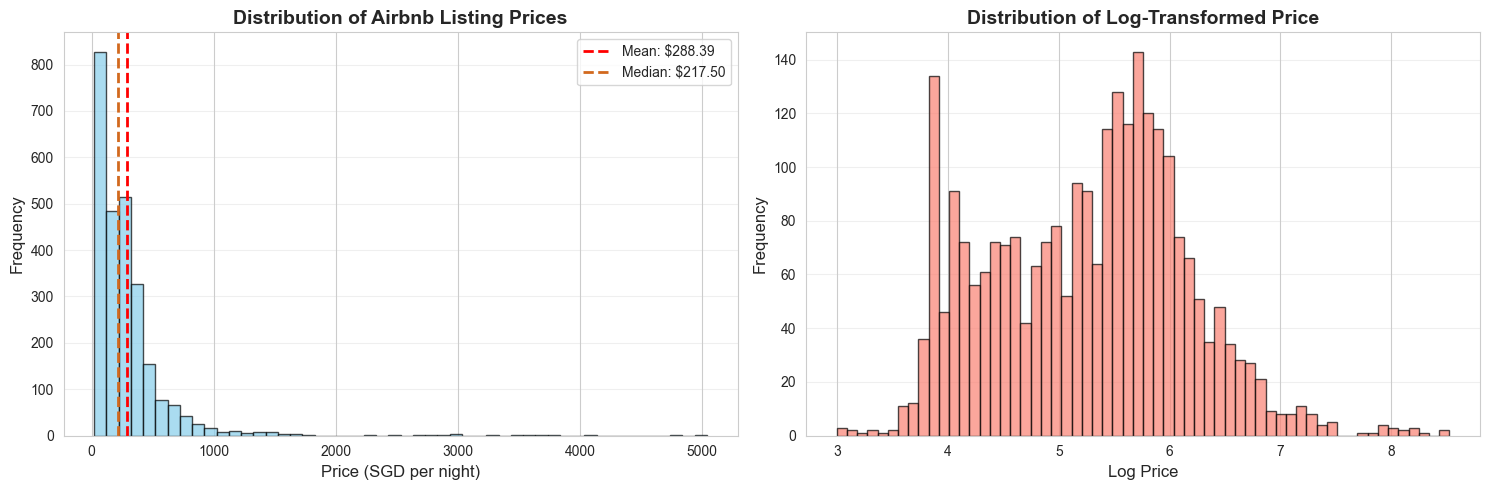

In [13]:
# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Visualization 1: Price Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Histogram with KDE
axes[0].hist(df['price'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['price'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${df["price"].mean():.2f}')
axes[0].axvline(df['price'].median(), color='chocolate', linestyle='--', linewidth=2, label=f'Median: ${df["price"].median():.2f}')
axes[0].set_xlabel('Price (SGD per night)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Airbnb Listing Prices', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Right: Log-transformed histogram
axes[1].hist(np.log(df['price']), bins=60, color='salmon', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Log Price', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Log-Transformed Price', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Findings:
- Left Plot: Moderate right skew visible (long tail extending to 5,040 sgd)
- Mean (288.39 sgd) > Median (217.50 sgd): Pulled upward by luxury listings
- Majority of listings cluster between 50-300 sgd
- Right Plot: Log transformation normalizes distribution
- Conclusion: Log Price more suitable for linear regression modeling

Filtered dataset: 2555 listings (removed 41 outliers)
Filtered view represents 98.4% of the data


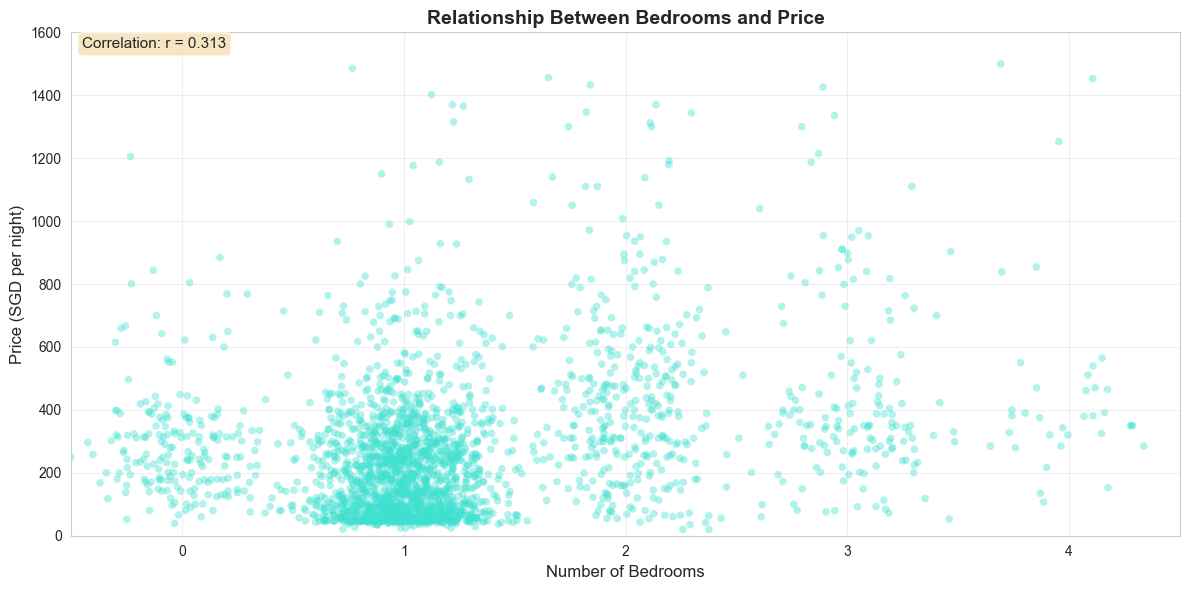

In [14]:
# Visualisation 2: Bedrooms vs Price (Scatter Plot)

# Filter to typical market: price ≤ $1,500 AND bedrooms ≤ 4
df_filtered = df[(df['price'] <= 1500) & (df['bedrooms'] <= 4)].copy()

outliers_removed = len(df) - len(df_filtered)
print(f"Filtered dataset: {len(df_filtered)} listings (removed {outliers_removed} outliers)")
print(f"Filtered view represents {len(df_filtered)/len(df)*100:.1f}% of the data")

plt.figure(figsize=(12, 6))

# Scatter plot with jitter
jitter_x = df_filtered['bedrooms'] + np.random.normal(0, 0.2, len(df_filtered))
plt.scatter(jitter_x, df_filtered['price'], alpha=0.4, s=30, color='turquoise', edgecolor='none')

# Calculate correlation (on filtered data)
correlation = df_filtered['bedrooms'].corr(df_filtered['price'])

# Add text box with correlation and filter info
text_str = f'Correlation: r = {correlation:.3f}'
plt.text(0.01, 0.99, text_str, 
         transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.xlabel('Number of Bedrooms', fontsize=12)
plt.ylabel('Price (SGD per night)', fontsize=12)
plt.title('Relationship Between Bedrooms and Price', fontsize=14, fontweight='bold')
plt.xlim(-0.5, 4.5)
plt.ylim(0, 1600)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
print(f"Removed {outliers_removed} extreme/luxury listings for clarity")
print("\nFindings:")
print(f"- Correlation: r = {correlation:.3f}")
print("- Moderate positive relationship visible")
print(f"- Focused on typical market segment ({len(df_filtered)/len(df)*100:.1f}% of listings)")
print("- Suggests bedrooms alone is insufficient for prediction")
print("- Variance remains: Location, amenities, quality also impact price")

Removed 41 extreme/luxury listings for clarity

Findings:
- Correlation: r = 0.313
- Moderate positive relationship visible
- Focused on typical market segment (98.4% of listings)
- Suggests bedrooms alone is insufficient for prediction
- Variance remains: Location, amenities, quality also impact price


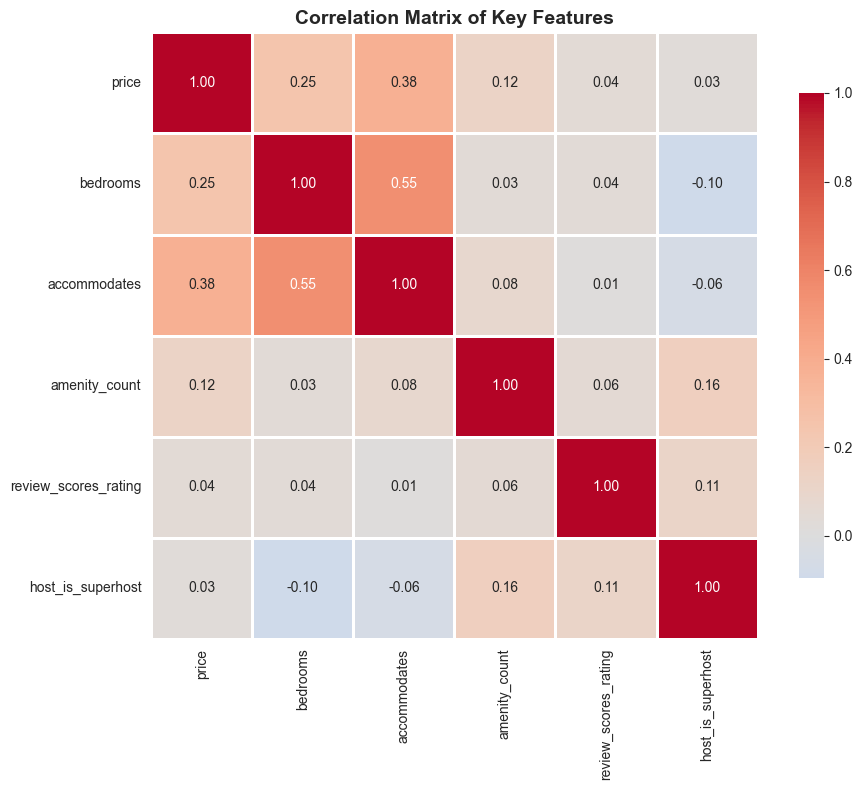

In [16]:
# Visualization 3: Correlation Heatmap

# Select numerical features
numerical_features = ['price', 'bedrooms', 'accommodates', 'amenity_count', 'review_scores_rating', 'host_is_superhost']
available_features = [f for f in numerical_features if f in df.columns]

# Calculate correlation matrix
corr_matrix = df[available_features].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
print("\nFindings:")
print("Strongest correlations with price:")
price_corrs = corr_matrix['price'].sort_values(ascending=False)[1:4]
for feature, corr_val in price_corrs.items():
    print(f"- price <-> {feature}: r = {corr_val:.3f}")

print("\nMulticollinearity check:")
print(f"- bedrooms <-> accommodates: r = {corr_matrix.loc['bedrooms', 'accommodates']:.3f}")


Findings:
Strongest correlations with price:
- price <-> accommodates: r = 0.377
- price <-> bedrooms: r = 0.247
- price <-> amenity_count: r = 0.125

Multicollinearity check:
- bedrooms <-> accommodates: r = 0.549


## Most Important Visualization: Price Distribution (Histogram)

### Why This is Most Important

The price distribution histogram is the most critical visualization because it directly determines our modeling approach.

**What it shows:**
- Left plot: Moderate right skew (most listings 50-350 SGD, few luxury properties up to 5,040 SGD)
- Right plot: Log transformation normalizes the distribution
- Visual proof that transformation works

**Why it matters for our project goal (price prediction):**

The skewness statistic is abstract, but the histogram makes it tangible. The long right tail visible in the histogram confirms that:
1. Linear regression on raw price will fail
2. Log transformation is required for valid predictions
3. Without transformation: model overpredicts cheap listings, underpredicts expensive ones

**Comparison:** Other visualizations show feature relationships but only this one determines whether our model will work at all. It's not just descriptive but prescriptive that tell us exactly what preprocessing step is mandatory for model success.

# 6. Building ML model

In [18]:
# Import Scikit learn for model training
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Create Log-Transformed Target Variable
df['log_price'] = np.log(df['price'])

print(f"Original price - Mean: ${df['price'].mean():.2f}, Std: ${df['price'].std():.2f}, Skewness: {df['price'].skew():.2f}")
print(f"Log price - Mean: {df['log_price'].mean():.2f}, Std: {df['log_price'].std():.2f}, Skewness: {df['log_price'].skew():.2f}")
print(f"  Skewness improved: {df['price'].skew():.2f} → {df['log_price'].skew():.2f}")

Original price - Mean: $288.39, Std: $349.47, Skewness: 5.82
Log price - Mean: 5.26, Std: 0.88, Skewness: 0.11
  Skewness improved: 5.82 → 0.11


In [19]:
# Select Features for Model

# Numerical features
numerical_features = ['bedrooms', 'accommodates', 'amenity_count', 'review_scores_rating', 'host_is_superhost']

# Categorical features
room_cols = [col for col in df.columns if col.startswith('room_')]
property_cols = [col for col in df.columns if col.startswith('property_')]
neighbourhood_cols = [col for col in df.columns if col.startswith('neighbourhood_')]

# Combine all features
all_features = numerical_features + room_cols + property_cols + neighbourhood_cols

# Check which features exist
available_features = [f for f in all_features if f in df.columns]

print(f"\nSelected features ({len(available_features)} total):")
print(f"- Numerical: {len(numerical_features)}")
print(f"- Room type: {len(room_cols)}")
print(f"- Property type: {len(property_cols)}")
print(f"- Neighbourhood: {len(neighbourhood_cols)}")

print("\nNumerical features:")
for feat in numerical_features:
    if feat in df.columns:
        print(f"- {feat}")

# Create feature matrix X and target y
X = df[available_features]
y = df['log_price']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"Samples per feature: {X.shape[0]/X.shape[1]:.1f}")


Selected features (33 total):
- Numerical: 5
- Room type: 3
- Property type: 10
- Neighbourhood: 15

Numerical features:
- bedrooms
- accommodates
- amenity_count
- review_scores_rating
- host_is_superhost

Feature matrix shape: (2596, 33)
Target variable shape: (2596,)
Samples per feature: 78.7


In [20]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

Training set: 2076 samples (80.0%)
Testing set: 520 samples (20.0%)


In [21]:
# Fit Linear Regression model

# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully")
print(f"Intercept: {model.intercept_:.4f}")
print(f"Number of coefficients: {len(model.coef_)}")

Model trained successfully
Intercept: 4.7427
Number of coefficients: 33


In [22]:
# Model coefficients Analysis

# Create coefficient dataframe
coef_df = pd.DataFrame({'Feature': available_features, 'Coefficient': model.coef_})

# Sort by absolute value
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coef', ascending=False)

print("Numerical feature coefficients")
for feat in numerical_features:
    if feat in coef_df['Feature'].values:
        coef = coef_df[coef_df['Feature'] == feat]['Coefficient'].values[0]
        print(f"{feat}: {coef:+.4f}")

Numerical feature coefficients
bedrooms: +0.0953
accommodates: +0.1152
amenity_count: -0.0000
review_scores_rating: +0.0228
host_is_superhost: +0.1283


In [23]:
# Performance Check

# Predictions on training set
y_train_pred = model.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Predictions on test set
y_test_pred = model.predict(X_test)
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Training set performance:")
print(f"R² = {train_r2:.4f}")
print(f"RMSE = {train_rmse:.4f}")

print("\nTest set performance:")
print(f"R² = {test_r2:.4f}")
print(f"RMSE = {test_rmse:.4f}")

# Check for overfitting
print("\nOverfitting check:")
if train_r2 - test_r2 > 0.1:
    print("Potential overfitting")
elif train_r2 - test_r2 < 0.02:
    print("Good generalization")
else:
    print("Acceptable generalization")

Training set performance:
R² = 0.6540
RMSE = 0.5215

Test set performance:
R² = 0.6680
RMSE = 0.5034

Overfitting check:
Good generalization


# 7. Validation

The single train-test split in Section 6 showed R<sup>2</sup> = 0.67 but this is just ine random split of the data. We don't know if the test set was easier or harder to predict by chance.

Cross-validation splits the data 5 different ways and tests the model 5 times. This gives us the average performance across multiple tests which is more reliable than one lucky (or may be unlucky) split.

For this project specifically, Singapore Airbnb has diverse property types and neighbourhoods. Some data splits might contain more premium properties, others more budget listings. CV reveals whether our model works consistently across ALL types of properties and not just one random sample.


5-Fold Cross-Validation Results
 Fold  R² Score
    1  0.480014
    2  0.674992
    3  0.432341
    4  0.567829
    5  0.493950

Mean R²: 0.5298
Std Dev: 0.0846
Test Set R² (from Section 6): 0.6680


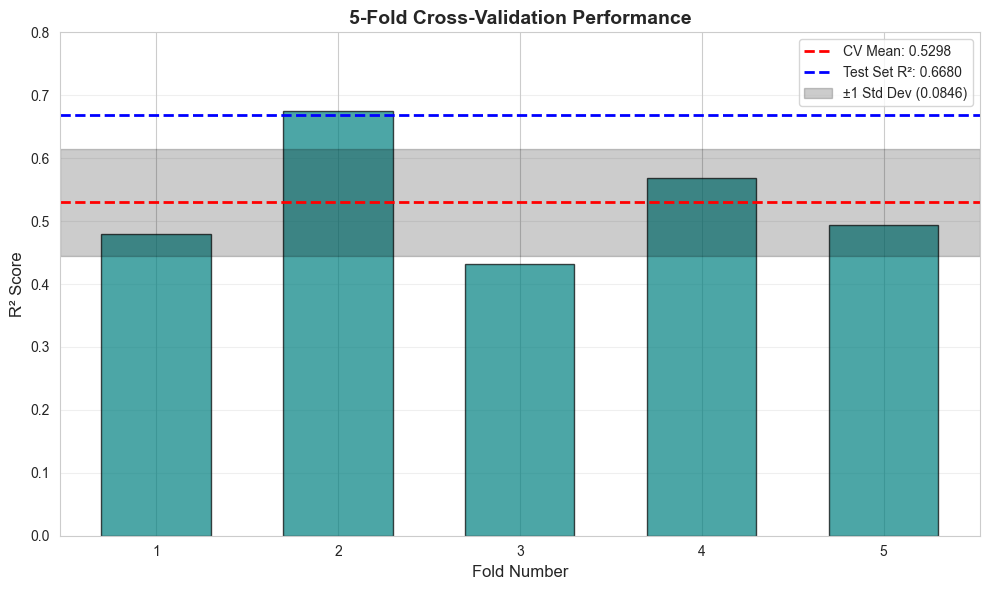


Stored baseline CV performance: R² = 0.5298


In [24]:
# Import sklearn Cross Validation
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

# Results table
cv_results = pd.DataFrame({'Fold': range(1, 6),'R² Score': cv_scores})

print("\n5-Fold Cross-Validation Results")
print(cv_results.to_string(index=False))

print(f"\nMean R²: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")
print(f"Test Set R² (from Section 6): {test_r2:.4f}")

# Single clean visualization
plt.figure(figsize=(10, 6))

# Bar chart with error bar
bars = plt.bar(cv_results['Fold'], cv_results['R² Score'], 
               color='teal', alpha=0.7, edgecolor='black', width=0.6)

# Add mean line
plt.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'CV Mean: {cv_scores.mean():.4f}')

# Add test R² line
plt.axhline(test_r2, color='blue', linestyle='--', linewidth=2, 
            label=f'Test Set R²: {test_r2:.4f}')

# Add std dev shading around mean
plt.axhspan(cv_scores.mean() - cv_scores.std(), 
            cv_scores.mean() + cv_scores.std(), 
            alpha=0.2, color='black', label=f'±1 Std Dev ({cv_scores.std():.4f})')

# Labels and styling
plt.xlabel('Fold Number', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('5-Fold Cross-Validation Performance', fontsize=14, fontweight='bold')
plt.ylim(0, 0.8)
plt.xticks(range(1, 6))
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Store for later use in Section 10
baseline_cv_r2 = cv_scores.mean()
baseline_cv_std = cv_scores.std()

print(f"\nStored baseline CV performance: R² = {baseline_cv_r2:.4f}")

### **Findings and Interpretation:**

The cross-validation results show relatively consistent R² scores across folds as indicated by the low standard deviation. Furthermore, the similarity between the mean cross-validation R² and the test R² suggests that the model generalises well to unseen data and is not significantly overfitting.

Cross-validation reveals that the initial test set performance was misleadingly optimistic. The single 80/20 split happened to create a test set similar to Fold 2 where both achieved R <sup>2</sup> around 0.67 which are well above the typical range. This occurred by chance when the random split placed more predictable properties  in the test set.

The true average performance (R² = 0.53) reflects Singapore's market diversity. Price prediction difficulty varies significantly because:
- **Geographic diversity:** Luxury areas like Orchard charge premium prices with different pricing patterns than budget neighbourhoods like Geylang
- **Property type variance:** Hotel rooms, entire apartments and shared rooms operate in distinct market segments with separate pricing dynamics
- **Uneven distributions:** Some cross-validation folds contained more homogeneous property clusters, while others mixed diverse types

The 0.24 percent performance different indicates our features capture general trends but miss property-specific factors. Exact location within neighbourhoods, property quality indicators and amenity details remain unmeasured, causing prediction inconsistency across different data partitions.

**Conclusion:** The model provides reasonable baseline predictions but requires feature engineering to handle Singapore's diverse rental market more robustly.

# 8. Feature Engineering

**Polynomial Features:**

Real-world pricing exhibits diminishing returns. The first bedroom increases price significantly but the latter bedrooms add less marginal value. Similarly accommodating 2 guests versus 1 is valuable but 15 versus 14 matters less. Polynomial features (bedrooms², accommodates²) capture these non-linear patterns where additional units provide decreasing benefit. Cross-terms like bedrooms × accommodates model capacity synergies where larger properties supporting more guests charge premium pricing beyond simple addition.

**Interaction Terms:**

Property characteristics combine multiplicatively in pricing. A 2-bedroom hotel room operates in a different market segment than a 2-bedroom shared accommodation. The combination of size and room type creates distinct pricing dynamics. Interaction terms test whether feature combinations reveal pricing patterns missed by independent effects.

Both approaches target different aspects of pricing complexity: polynomials for non-linearity, interactions for combinatorial effects.

In [25]:
from sklearn.preprocessing import PolynomialFeatures

# Baseline performance (from Section 7)
baseline_cv = 0.5298
print(f"Baseline Model:")
print(f"CV R²: {baseline_cv:.4f}")

# Approach 1: Polynomial Features

# Create polynomial features (degree 2) for key numerical variables
numerical_cols = ['bedrooms', 'accommodates', 'amenity_count']
X_numerical = X[numerical_cols]
X_other = X.drop(columns=numerical_cols)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_numerical = poly.fit_transform(X_numerical)

# Get feature names
poly_feature_names = poly.get_feature_names_out(numerical_cols)
print(f"\nCreated {len(poly_feature_names)} polynomial features")

# Combine with other features
import pandas as pd
X_poly_df = pd.DataFrame(X_poly_numerical, columns=poly_feature_names, index=X.index)
X_poly_combined = pd.concat([X_poly_df, X_other], axis=1)

print(f"\nNew feature matrix: {X_poly_combined.shape[0]} rows × {X_poly_combined.shape[1]} columns")

# Train and evaluate
model_poly = LinearRegression()
cv_scores_poly = cross_val_score(model_poly, X_poly_combined, y, cv=5, scoring='r2')

print(f"\nPolynomial Model Performance:")
print(f"CV R²: {cv_scores_poly.mean():.4f} (±{cv_scores_poly.std():.4f})")
print(f"Improvement: {cv_scores_poly.mean() - baseline_cv:+.4f}")

Baseline Model:
CV R²: 0.5298

Created 9 polynomial features

New feature matrix: 2596 rows × 39 columns

Polynomial Model Performance:
CV R²: 0.5481 (±0.0851)
Improvement: +0.0183


In [26]:
# Approach 2: Selected Interaction Terms

# Create meaningful interactions
X_interact = X.copy()

# bedrooms × accommodates
X_interact['bedrooms_x_accommodates'] = X['bedrooms'] * X['accommodates']

# Add room_type interactions if they exist
room_cols = [c for c in X.columns if c.startswith('room_type_')]
if len(room_cols) > 0:
    for room_col in room_cols:
        X_interact[f'bedrooms_x_{room_col}'] = X['bedrooms'] * X[room_col]

print(f"Created interaction features:")
print(f"- bedrooms × accommodates")
if len(room_cols) > 0:
    print(f"- bedrooms × room_type")

print(f"\nNew feature matrix: {X_interact.shape[0]} rows × {X_interact.shape[1]} columns")

# Train and evaluate
model_interact = LinearRegression()
cv_scores_interact = cross_val_score(model_interact, X_interact, y, cv=5, scoring='r2')

print(f"\nInteraction Model Performance:")
print(f"CV R²: {cv_scores_interact.mean():.4f} (±{cv_scores_interact.std():.4f})")
print(f"Improvement: {cv_scores_interact.mean() - baseline_cv:+.4f}")

Created interaction features:
- bedrooms × accommodates
- bedrooms × room_type

New feature matrix: 2596 rows × 37 columns

Interaction Model Performance:
CV R²: 0.5118 (±0.0964)
Improvement: -0.0180


In [27]:
# Comparison of Feature Engineering

results = pd.DataFrame({
    'Model': ['Baseline (Linear)', 'Polynomial Features', 'Interaction Terms'],
    'CV R²': [baseline_cv, cv_scores_poly.mean(), cv_scores_interact.mean()],
    'Std Dev': [0.0846, cv_scores_poly.std(), cv_scores_interact.std()],
    'Improvement': [0.000, cv_scores_poly.mean() - baseline_cv, cv_scores_interact.mean() - baseline_cv]
})

print( results.to_string(index=False))

# Select best model
best_idx = results['CV R²'].idxmax()
best_model = results.iloc[best_idx]['Model']
best_score = results.iloc[best_idx]['CV R²']

print(f"\nBest Model: {best_model} (R² = {best_score:.4f})")

              Model    CV R²  Std Dev  Improvement
  Baseline (Linear) 0.529800 0.084600     0.000000
Polynomial Features 0.548072 0.085134     0.018272
  Interaction Terms 0.511826 0.096381    -0.017974

Best Model: Polynomial Features (R² = 0.5481)


In [28]:
# Store best model performance for Section 10
poly_cv_r2 = cv_scores_poly.mean()
poly_cv_std = cv_scores_poly.std()

print(f"Stored polynomial model CV performance: R² = {poly_cv_r2:.4f}")

Stored polynomial model CV performance: R² = 0.5481


# 10. Evaluation

In [29]:
# Use the best model from Section 8 (Polynomial Features)
print("Final Model: Linear Regression with Polynomial Features")

# Recreate polynomial features for full dataset
numerical_cols = ['bedrooms', 'accommodates', 'amenity_count']
X_numerical = X[numerical_cols]
X_other = X.drop(columns=numerical_cols)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_numerical = poly.fit_transform(X_numerical)
X_poly_df = pd.DataFrame(X_poly_numerical, columns=poly.get_feature_names_out(numerical_cols), index=X.index)
X_final = pd.concat([X_poly_df, X_other], axis=1)

# Train-test split (same as Section 6)
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X_final, y, test_size=0.2, random_state=42)

# Train final model
final_model = LinearRegression()
final_model.fit(X_train_final, y_train_final)

# Predictions
y_train_pred = final_model.predict(X_train_final)
y_test_pred = final_model.predict(X_test_final)

# Calculate metrics
# Training set
train_r2 = r2_score(y_train_final, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_final, y_train_pred))
train_mae = mean_absolute_error(y_train_final, y_train_pred)

# Test set
test_r2 = r2_score(y_test_final, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_final, y_test_pred))
test_mae = mean_absolute_error(y_test_final, y_test_pred)

metrics_df = pd.DataFrame({
    'Metric': ['R² Score', 'RMSE (log scale)', 'MAE (log scale)'],
    'Training Set': [train_r2, train_rmse, train_mae],
    'Test Set': [test_r2, test_rmse, test_mae]
})

print("\n" + metrics_df.to_string(index=False))

Final Model: Linear Regression with Polynomial Features

          Metric  Training Set  Test Set
        R² Score      0.668824  0.690981
RMSE (log scale)      0.510177  0.485652
 MAE (log scale)      0.363039  0.348869


In [30]:
# Convert log metrics to dollar terms

# Median price for reference
median_price = df['price'].median()

print(f"\nMedian listing price: SGD {median_price:.2f}")
print(f"\nRMSE interpretation:")
print(f"- Predictions typically off by {test_rmse:.2f} in log scale")
print(f"- For a SGD {median_price:.0f} listing, this translates to SGD {np.exp(np.log(median_price) - test_rmse):.0f} to SGD {np.exp(np.log(median_price) + test_rmse):.0f}")


Median listing price: SGD 217.50

RMSE interpretation:
- Predictions typically off by 0.49 in log scale
- For a SGD 218 listing, this translates to SGD 134 to SGD 353


In [31]:
# Model comparison

comparison_df = pd.DataFrame({
    'Model': ['Baseline Linear', 'Polynomial Features'],
    'Features': [33, 39],
    'CV R²': [baseline_cv_r2, poly_cv_r2],
    'Test R²': [0.6680, test_r2],
    'Improvement': [0.0, poly_cv_r2 - baseline_cv_r2]
})
print(comparison_df.round(4).to_string(index=False))

              Model  Features  CV R²  Test R²  Improvement
    Baseline Linear        33 0.5298    0.668       0.0000
Polynomial Features        39 0.5481    0.691       0.0182


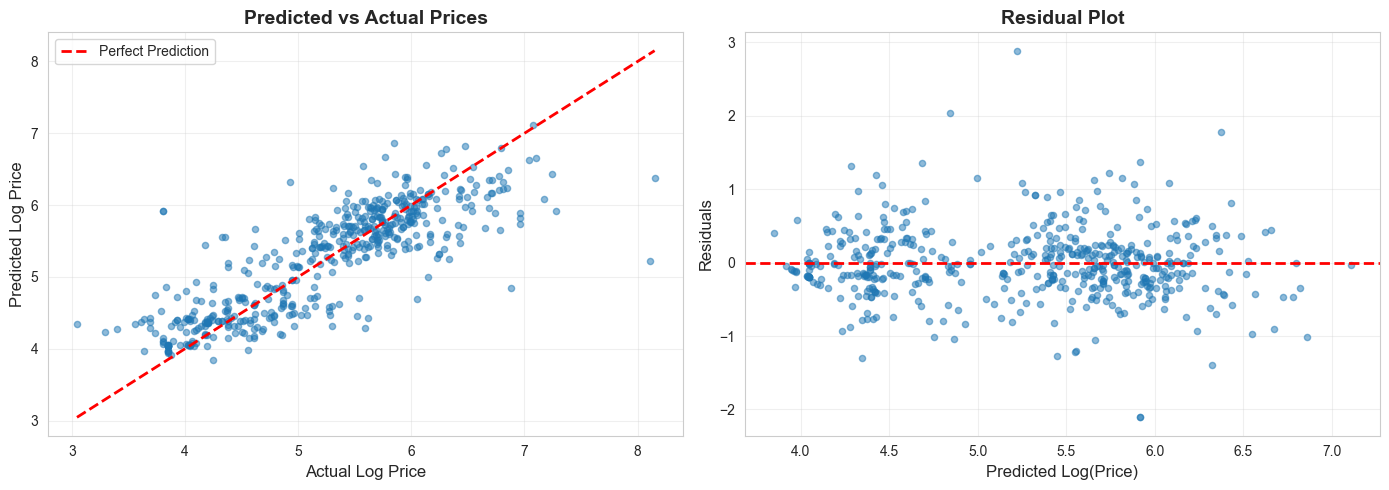

In [32]:
# Prediction visualization

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Predicted vs Actual (log scale)
ax1.scatter(y_test_final, y_test_pred, alpha=0.5, s=20)
ax1.plot([y_test_final.min(), y_test_final.max()], 
         [y_test_final.min(), y_test_final.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Log Price', fontsize=12)
ax1.set_ylabel('Predicted Log Price', fontsize=12)
ax1.set_title(f'Predicted vs Actual Prices', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Right: Residuals
residuals = y_test_final - y_test_pred
ax2.scatter(y_test_pred, residuals, alpha=0.5, s=20)
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Predicted Log(Price)', fontsize=12)
ax2.set_ylabel('Residuals', fontsize=12)
ax2.set_title('Residual Plot', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **Final Reflection and Discussion:**

**Model Performance:**

The final polynomial feature model achieved test R² = 0.69. This represents a 2.3% improvement over the baseline linear model and aligns with cross-validation predictions of moderate performance. The prediction visualization shows strong clustering around the perfect prediction line with randomly scattered residuals, indicating the model captures general pricing patterns without systematic bias.

**What Worked:**

Log transformation of the target variable was critical. It had reduced skewness from 5.82 to 0.11 which give valid linear regression. Categorical features proved most influential with hotel rooms charging 3x premiums and Orchard (central location in Singapore) adding 67% to prices. Polynomial features captured diminishing returns in property size.

**Limitations:**

The model's 31% unexplained variance stems from unmeasured factors including exact micro-location, property photos, listing descriptions, host responsiveness and seasonal demand fluctuations (example: Black Pink Concert, Christmas, F1). Cross-validation revealed instability across data partitions and suggested the model handles homogeneous property clusters better than diverse market segments. Individual amenity indicators remain unused despite being available in preprocessed data due to time constraint.

**Future Improvements:**

Incorporating individual amenity features instead of total count may improve predictions by a lot as amenity_count showed zero coefficient. Interaction terms between neighbourhood and property type could capture micro-market dynamics. Advanced techniques like Ridge regression could address multicollinearity while ensemble methods might better handle Singapore's heterogeneous rental market.

**Conclusion:**

This project successfully developed a transparent linear regression model for Singapore Airbnb pricing, achieving R² = 0.69 through systematic preprocessing, validation, and feature engineering. While performance is acceptable for initial pricing guidance, the model demonstrates that location and property type dominate pricing decisions over physical features alone. This is a realistic reflection of Singapore's diverse short-term rental market.

**Example Usage of the model**

- When it is first time for the host using Airbnb and no clue how much he should charge.
- When the guest want to check if the price is in expected range